# Where does the reorder point come from? A house rule, a planning table, a forecast or your own rule

A small café sells espresso beans, oat milk and chai syrup. The buyer uses a classic rule: when stock gets low, order more. Two numbers drive it. The **reorder point** `s` is the stock level at which the buyer orders, and the **order-up-to level** `S` is the level the order brings the stock back up to.

**Where do `s` and `S` come from?** In practice, from anywhere: one rule for the whole shop, a planner's table, a demand forecast, or a formula the team has used for years. Stockcast's `ReorderPointPolicy` takes them from any of these sources, and the rule itself never changes. We give the café's policy its levels in four ways, then replay all of them on the same demand and compare:

| Source of `s` and `S` | How you pass it to `fit` |
|---|---|
| one pair for every product | two numbers |
| one value per product | a dict, or a column of a planning table |
| a demand forecast | a dated table of forecast quantiles |
| your own rule | a small class that computes the levels |

[Notebook 05b](05b_reorder_points_and_review_frequency.ipynb) explains how review timing sets the window a reorder point must cover. Here we focus on where the numbers come from.

In [1]:
import numpy as np
import pandas as pd

# Show every number with two decimals.
pd.options.display.float_format = "{:.2f}".format

## 1. The café

Espresso beans sell about 9 units a day, oat milk 5 and chai syrup 1.5. Deliveries take **two days**, and the buyer checks stock **every three days**. We replay eight weeks of demand; the first week is a warm-up, so every policy is scored on the same last seven weeks, after the opening stock has been used up.

In [2]:
opening_date = pd.Timestamp("2026-01-05")
rates = {"espresso_beans": 9.0, "oat_milk": 5.0, "chai_syrup": 1.5}
skus = list(rates)
lead_days, review_days = 2, 3
days, warmup_days = 56, 7

rng = np.random.default_rng(11)
dates = pd.date_range(opening_date + pd.Timedelta(days=1), periods=days, freq="D")
demand = pd.DataFrame(
    [
        {
            "unique_id": sku,
            "period": period,
            "date": date,
            "y": float(rng.poisson(rate)),
        }
        for sku, rate in rates.items()
        for period, date in enumerate(dates)
    ]
)

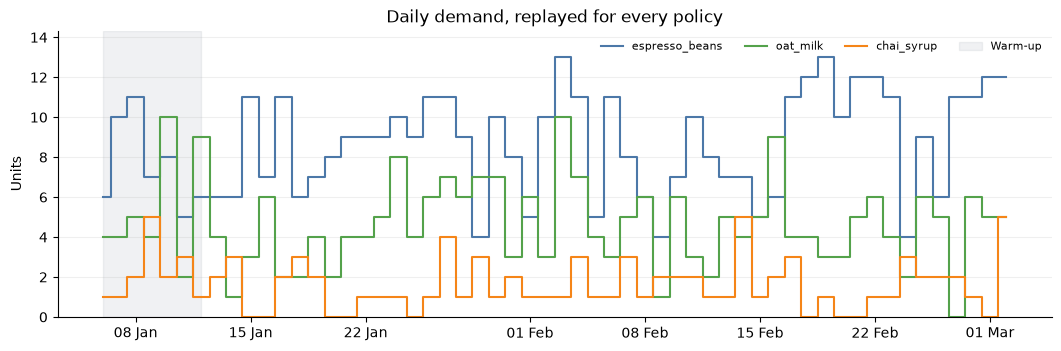

In [3]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

SKU_COLORS = ["#4C78A8", "#54A24B", "#F58518"]


def style_axis(ax):
    ax.set_ylim(0, ax.get_ylim()[1] * 1.05)
    ax.grid(axis="y", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)


fig, ax = plt.subplots(figsize=(10.5, 3.4), layout="constrained")
for sku, color in zip(skus, SKU_COLORS):
    series = demand.loc[demand["unique_id"].eq(sku)]
    ax.step(series["date"], series["y"], where="mid", color=color, label=sku)
ax.axvspan(
    dates[0],
    dates[warmup_days - 1],
    color="#9CA3AF",
    alpha=0.15,
    label="Warm-up",
)
ax.set(title="Daily demand, replayed for every policy", ylabel="Units")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
style_axis(ax)
ax.legend(frameon=False, fontsize=8, ncol=4, loc="upper right")
plt.show()

Every policy starts from the same stock on the shelf, with nothing on order. At each review the policy compares the **inventory position** with `s`. The inventory position is the stock on the shelf plus the stock on order (minus any backlog): everything the buyer can count on.

In [4]:
from stockcast.core import InventoryStateDataFrame

opening = InventoryStateDataFrame.from_observed(
    pd.DataFrame({"unique_id": skus, "on_hand": [40.0, 25.0, 8.0]}),
    opening_date=opening_date,
)

## 2. One pair for every product

The simplest source is a single house rule: *reorder at 20, fill up to 50*. Pass the two numbers to `fit`, and the pair applies to every product.

To see the rule at work, we ask the policy for one decision on the opening stock with `predict()`. It only returns the order it would place; it does not change the stock.

In [5]:
from stockcast.policies import ReorderPointPolicy

one_pair = ReorderPointPolicy(
    lead_time=lead_days,
    review_period=review_days,
    allow_backorders=False,
)
one_pair.fit(reorder_point=20.0, order_up_to_level=50.0)

decision = one_pair.predict(opening, current_period=0).get_dataframe()
decision[
    [
        "unique_id",
        "inventory_position",
        "reorder_point",
        "target_level",
        "order_quantity",
    ]
]

,unique_id,inventory_position,reorder_point,target_level,order_quantity
0,espresso_beans,40.00,20.00,50.00,0.00
1,oat_milk,25.00,20.00,50.00,0.00
2,chai_syrup,8.00,20.00,50.00,42.00


Only chai syrup is at or below 20, so only chai is ordered: 42 units, enough for about four weeks of its sales. Espresso beans sell six times faster but wait with 40 units. One pair for very different products is easy to state, but it rarely fits all of them; section 6 shows what it costs.

## 3. One value per product: a planning table

Most planners keep a table with one `s` and one `S` per product. Pass its columns to `fit`; a Series indexed by product works, and so does a plain dict such as `{"espresso_beans": 35.0, ...}`.

In [6]:
plan = pd.DataFrame(
    {
        "unique_id": skus,
        "s": [35.0, 20.0, 6.0],
        "S": [75.0, 45.0, 14.0],
    }
).set_index("unique_id")

planner_table = ReorderPointPolicy(
    lead_time=lead_days,
    review_period=review_days,
    allow_backorders=False,
)
planner_table.fit(reorder_point=plan["s"], order_up_to_level=plan["S"])
planner_table.get_parameters()

,unique_id,reorder_point,order_up_to_level
0,espresso_beans,35.00,75.00
1,oat_milk,20.00,45.00
2,chai_syrup,6.00,14.00


Stockcast checks the values before any run: every number is finite, `s` is not negative, `S` is at least `s`, and both name the same products. A table with the two columns swapped is refused at once: *order-up-to levels must be greater than or equal to reorder points*.

### The same table with a fixed order size

Some products are bought in fixed lots: a pallet, a case, a minimum order. Give `order_quantity` to the constructor and the policy orders exactly that amount, `Q`, whenever the position is at or below `s`. This is called an `(s,Q)` policy, and it needs `s` only.

In [7]:
lot_size = 30.0
fixed_lot = ReorderPointPolicy(
    lead_time=lead_days,
    review_period=review_days,
    order_quantity=lot_size,
    allow_backorders=False,
)
fixed_lot.fit(reorder_point=plan["s"])
fixed_lot.get_parameters()

,unique_id,reorder_point,order_quantity
0,espresso_beans,35.00,30.00
1,oat_milk,20.00,30.00
2,chai_syrup,6.00,30.00


## 4. A demand forecast

A forecast gives `s` a clear meaning: *the 95% quantile of demand over the window this decision must cover*. With deliveries in two days and a review every three days, an order not placed today can next be placed in three days and arrives two days after that. So `s` must cover **`L + R = 2 + 3 = 5` days** of demand.

Here the forecast is the known Poisson rate. Five days of Poisson demand is again Poisson, with mean `5 × rate`, and `s` is its 95% quantile: a quantile of the five-day total, not a sum of five daily quantiles. For `S` we add one review period of average demand on top of `s`, a common planning choice.

In [8]:
import math


def poisson_quantile(probability, mean):
    """Smallest k with P(N <= k) >= probability, for N ~ Poisson(mean)."""
    k, pmf = 0, math.exp(-mean)
    cdf = pmf
    while cdf < probability:
        k += 1
        pmf *= mean / k
        cdf += pmf
    return float(k)


horizon = lead_days + review_days
forecast_targets = pd.DataFrame(
    {
        "unique_id": skus,
        "s_q95": [poisson_quantile(0.95, horizon * rate) for rate in rates.values()],
        "end": opening_date + pd.Timedelta(days=horizon),
    }
)
forecast_targets["S"] = forecast_targets["s_q95"] + [
    review_days * rate for rate in rates.values()
]
forecast_targets

,unique_id,s_q95,end,S
0,espresso_beans,56.00,2026-01-10,83.00
1,oat_milk,33.00,2026-01-10,48.00
2,chai_syrup,12.00,2026-01-10,16.50


Forecasts are **dated**, and the policy checks the dates. `forecast_origin` is the last day whose sales the forecast knew, `freq="D"` says one period is one day, and the `end` column is the last day `s` covers. `service_level=0.95` states that `s` is a 95% quantile. The policy checks that the window from origin to `end` is exactly its own five days and records all of it. A forecast for the wrong window, say only the two lead-time days, is refused: *target_df.end must equal 2026-01-10 00:00:00 for horizon 5*.

In [9]:
from_forecast = ReorderPointPolicy(
    lead_time=lead_days,
    review_period=review_days,
    freq="D",
    service_level=0.95,
    allow_backorders=False,
    date_column="end",
)
from_forecast.fit(
    forecast_targets,
    reorder_point_column="s_q95",
    order_up_to_column="S",
    forecast_origin=opening_date,
)
pd.Series(from_forecast.get_target_metadata(), name="recorded").to_frame()

,recorded
representation,direct_reorder_point_target
target_probability,0.95
reorder_horizon,5
target_source,external_direct
forecast_origin,2026-01-05T00:00:00
forecast_frequency,D
reorder_end_date,2026-01-10T00:00:00
order_up_to_representation,external_policy_level


The policy records what its levels mean: a direct quantile target at probability 0.95 over five days, from a forecast made on 5 January. This record travels with every run of the policy. If your `s` comes from a forecast but is not a quantile, for example an optimised `(s,S)` pair, keep the same call with `service_level=None`: the window is still checked, but no probability is claimed.

## 5. Your own rule

Many teams have a rule of their own. This café uses **days of cover**: reorder when the stock covers fewer than 4 days of recent sales, and fill up to 9 days. A `ReorderPointTargetProvider` packages such a rule as a small class. Its `provide()` method receives the table passed to `fit` and returns one row per product with `reorder_point` and `order_up_to_level`.

In [10]:
from stockcast.policies import ReorderPointTargetProvider, ReorderPointTargets


class DaysOfCover(ReorderPointTargetProvider):
    """s and S as days of recent sales, rounded up to whole units."""

    def __init__(self, reorder_days, order_up_to_days):
        self.reorder_days = reorder_days
        self.order_up_to_days = order_up_to_days

    def provide(self, target_data, *, sku_column):
        rate = target_data["daily_rate"]
        levels = pd.DataFrame(
            {
                sku_column: target_data[sku_column],
                "reorder_point": np.ceil(self.reorder_days * rate),
                "order_up_to_level": np.ceil(self.order_up_to_days * rate),
            }
        )
        return ReorderPointTargets(frame=levels)

    def to_manifest(self):
        # Recorded with every run, so the rule's settings travel with the results.
        return {
            **super().to_manifest(),
            "reorder_days": self.reorder_days,
            "order_up_to_days": self.order_up_to_days,
        }

The café's average daily sales over the last four weeks are typed in below; in practice you would compute them from your sales history. Stockcast checks the provider's levels with the same rules as a planning table.

In [11]:
recent_sales = pd.DataFrame({"unique_id": skus, "daily_rate": [8.6, 5.3, 1.4]})

days_of_cover = ReorderPointPolicy(
    lead_time=lead_days,
    review_period=review_days,
    allow_backorders=False,
)
days_of_cover.fit(
    recent_sales,
    target_provider=DaysOfCover(reorder_days=4, order_up_to_days=9),
)
days_of_cover.get_parameters()

,unique_id,reorder_point,order_up_to_level
0,espresso_beans,35.00,78.00
1,oat_milk,22.00,48.00
2,chai_syrup,6.00,13.00


## 6. Compare every source on the same demand

First, the levels side by side. Every policy can report its levels through a decision on the opening stock, so we read `s` and `S` from `predict()` for each source. The `(s,Q)` policy has no `S`; its bar runs from `s` to `s + Q`, the highest the position can reach right after an order.

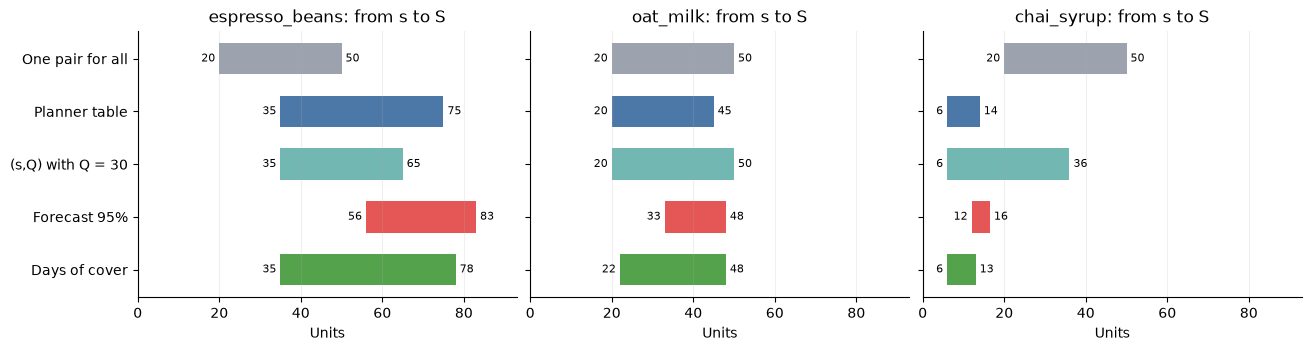

In [12]:
policies = {
    "One pair for all": one_pair,
    "Planner table": planner_table,
    "(s,Q) with Q = 30": fixed_lot,
    "Forecast 95%": from_forecast,
    "Days of cover": days_of_cover,
}
SOURCE_COLORS = ["#9CA3AF", "#4C78A8", "#72B7B2", "#E45756", "#54A24B"]

level_rows = []
for source, policy in policies.items():
    decision = policy.predict(opening, current_period=0).get_dataframe()
    # The (s,Q) policy has no S: use s + Q instead.
    top = decision["target_level"].fillna(decision["reorder_point"] + lot_size)
    level_rows.append(
        pd.DataFrame(
            {
                "source": source,
                "unique_id": decision["unique_id"],
                "s": decision["reorder_point"],
                "top": top,
            }
        )
    )
levels = pd.concat(level_rows, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True, layout="constrained")
for ax, sku in zip(axes, skus):
    rows = levels.loc[levels["unique_id"].eq(sku)]
    ax.barh(
        rows["source"],
        rows["top"] - rows["s"],
        left=rows["s"],
        color=SOURCE_COLORS,
        height=0.6,
    )
    for y, (s, top) in enumerate(zip(rows["s"], rows["top"])):
        ax.text(s, y, f"{s:.0f} ", ha="right", va="center", fontsize=8)
        ax.text(top, y, f" {top:.0f}", ha="left", va="center", fontsize=8)
    ax.set(title=f"{sku}: from s to S", xlabel="Units")
    ax.set_xlim(0, levels["top"].max() * 1.12)
    ax.grid(axis="x", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].invert_yaxis()
plt.show()

**What to notice:** the one pair is the same for every product, so it sits far below the other sources for espresso beans and far above them for chai syrup. The forecast gives espresso beans the highest `s`, 56, because it covers five days of the fastest seller at 95%. The planner table and days of cover land close together, since both follow each product's sales rate.

Now the run. `run_comparison` takes `{label: policy}` and gives every branch the same demand, its own copy of the opening stock, and the same warm-up, so the policies differ only in where their levels came from. Fixed levels carry no dates, so `freq="D"` tells the run that one period is one day.

In [13]:
from stockcast.core import SimulationEngine

comparison = SimulationEngine().run_comparison(
    policies,
    demand,
    opening,
    freq="D",
    warmup_periods=warmup_days,
)

Every branch is scored with `stockcast.evaluation` on the same costs: 0.05 per unit held per day, 2.00 per unit of lost sales, and 4.00 per order line (one product on one order).

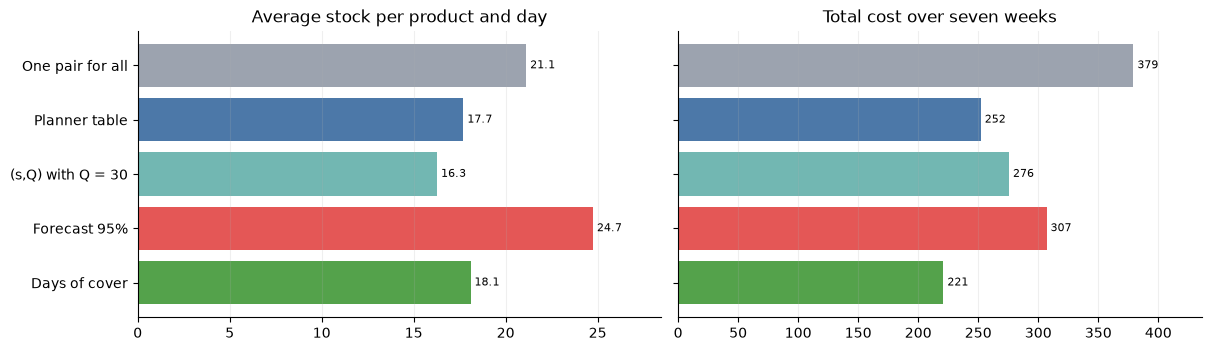

In [14]:
from stockcast.evaluation import (
    InventoryEvaluator,
    avg_on_hand,
    fill_rate,
    total_cost,
)

costs = {
    "holding_cost_per_unit_period": 0.05,
    "shortage_cost_per_unit": 2.0,
    "order_cost_per_sku_line": 4.0,
    "order_cost_per_unit": 0.0,
    "cost_components": ["holding", "shortage", "ordering"],
}
score_rows = []
for source in policies:
    evaluator = InventoryEvaluator()
    evaluator.fit(comparison[source])
    scores = evaluator.evaluate(
        [fill_rate, avg_on_hand, total_cost],
        groupby=["unique_id"],
        context=costs,
    )
    score_rows.append(scores.assign(source=source))
per_product = pd.concat(score_rows, ignore_index=True)

totals = per_product.groupby("source", sort=False).agg(
    avg_on_hand=("avg_on_hand", "mean"),
    total_cost=("total_cost", "sum"),
)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True, layout="constrained")
for ax, column, title, label in [
    (axes[0], "avg_on_hand", "Average stock per product and day", "{:.1f}"),
    (axes[1], "total_cost", "Total cost over seven weeks", "{:.0f}"),
]:
    ax.barh(totals.index, totals[column], color=SOURCE_COLORS)
    for y, value in enumerate(totals[column]):
        ax.text(value, y, " " + label.format(value), va="center", fontsize=8)
    ax.set(title=title)
    ax.set_xlim(0, totals[column].max() * 1.15)
    ax.grid(axis="x", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].invert_yaxis()
plt.show()

**What to notice:** the one pair is the most expensive source, 379, even though only the forecast holds more stock (24.7 units against 21.1). Days of cover is the cheapest at 221, followed by the planner table at 252. The `(s,Q)` policy holds the least stock, 16.3, but costs more than the planner table, because with less stock it loses more sales. The fill rate per product shows where each source wins or loses:

In [15]:
from IPython.display import display

# Fill rates sit close to 1, so this table shows three decimals.
fill_rates = per_product.pivot(index="source", columns="unique_id", values="fill_rate")
with pd.option_context("display.float_format", "{:.3f}".format):
    display(fill_rates.loc[list(policies), skus])

unique_id,espresso_beans,oat_milk,chai_syrup
source,,,
One pair for all,0.819,0.991,1.000
Planner table,0.970,0.986,0.987
"(s,Q) with Q = 30",0.947,0.959,0.974
Forecast 95%,1.000,1.000,0.993
Days of cover,1.000,1.000,0.974


The one pair serves only 81.9% of espresso demand, while chai syrup, with room for 50 units of a slow seller, never runs out: the cost comes from shortages on one product and idle stock on another. The forecast and days of cover serve all espresso and oat milk demand; days of cover gets there with less stock and falls short only on chai syrup now and then (0.974). These rankings belong to this replay and these costs; with other sales rates the balance moves, which is exactly what a comparison is for.

### Follow one product through its levels

Finally, the event table shows the rule at work. For espresso beans under the days-of-cover policy, every third day is a review: the position before it (white dots) is compared with `s`, and each order (orange) lifts the position back to `S`. Demand then pulls the position down until the next review.

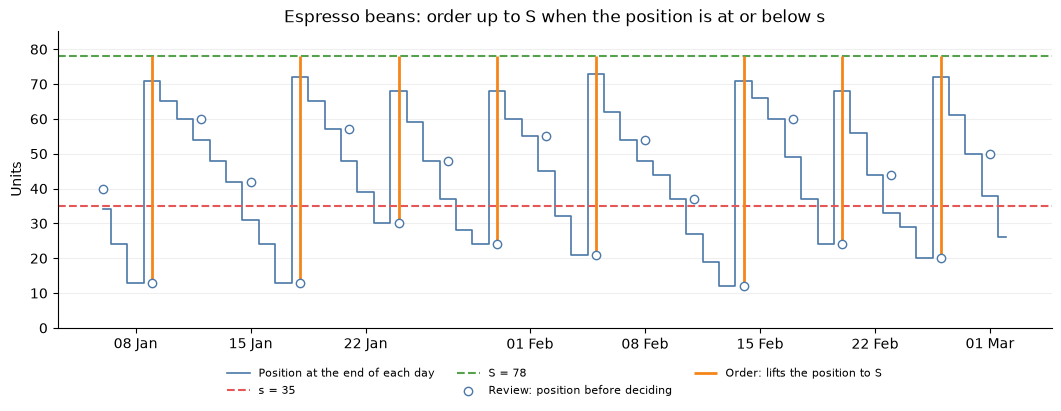

In [16]:
events = comparison["Days of cover"].to_event_frame()
beans = events.loc[
    events["event_type"].eq("period") & events["unique_id"].eq("espresso_beans")
]
beans_levels = levels.query(
    "source == 'Days of cover' and unique_id == 'espresso_beans'"
)
s, S = beans_levels["s"].item(), beans_levels["top"].item()
reviews = beans.loc[beans["is_review_period"]]
ordered = reviews.loc[reviews["order_quantity"].gt(0)]
# Every order was placed at or below s and lifted the position exactly to S.
assert (ordered["decision_inventory_position"] <= s).all()
assert np.allclose(
    ordered["decision_inventory_position"] + ordered["order_quantity"],
    S,
)

fig, ax = plt.subplots(figsize=(10.5, 4), layout="constrained")
ax.step(
    beans["date"],
    beans["inventory_position_end"],
    where="mid",
    color="#4C78A8",
    linewidth=1.2,
    label="Position at the end of each day",
)
ax.axhline(s, color="#E45756", linestyle="--", label=f"s = {s:.0f}")
ax.axhline(S, color="#54A24B", linestyle="--", label=f"S = {S:.0f}")
ax.scatter(
    reviews["date"],
    reviews["decision_inventory_position"],
    facecolor="white",
    edgecolor="#4C78A8",
    zorder=3,
    label="Review: position before deciding",
)
ax.vlines(
    ordered["date"],
    ordered["decision_inventory_position"],
    ordered["decision_inventory_position"] + ordered["order_quantity"],
    color="#F58518",
    linewidth=2,
    label="Order: lifts the position to S",
)
ax.set(
    title="Espresso beans: order up to S when the position is at or below s",
    ylabel="Units",
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
style_axis(ax)
ax.legend(
    frameon=False,
    fontsize=8,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
)
plt.show()